* [Theory](https://www.youtube.com/watch?v=hZ4a4NgM3u0)
* [Code](https://www.youtube.com/watch?v=MLAZu2mRbwk)


## Import Libraries

```
torch          → tensor math
torch.nn       → build encoder and decoder
torch.optim    → train the model
datasets       → get image dataset
transforms     → preprocess images
DataLoader     → feed images in batches
```




In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [25]:
# Defining the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Overall flow

```
Your code basically means:
1. Define batch size
2. Convert images into tensors
3. Load dataset in shuffled batches
```




```
What does DataLoader do?
It helps:
1. Load data
2. Create batches
3. Shuffle data
4. Feed data to model
```


In [26]:

BATCH_SIZE = 128

# Image from datasets are usually in PIL or Numpy array format or anyother format. But pytorch model needs torch.Tensor, so we convert the format
dataclass_transform = transforms.Compose([transforms.ToTensor()]) # Compose applies multiple transforms in sequence

train_dataset = datasets.MNIST(root = "./data", train = True, download = True, transform=dataclass_transform)

# We can also try on fashion mnsit
# train_dataset = datasets.FashionMNIST(root = "./data", train = True, download = True, transform=dataclass_transform)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)



# AutoEncoder



```
class AutoEncoder:

  # Encoder

  # Decoder

  # Forward():
    Encoder
    Decoder
```



# This is the heart of the model.



```
First: What is an AutoEncoder?

An autoencoder has 2 parts:
Input Image
     ↓
 Encoder
     ↓
Latent Space (compressed representation)
     ↓
 Decoder
     ↓
Reconstructed Image

Goal:
Output should look as close as possible to input
```




**latent_dim**
```
This is the compressed representation size.
You are compressing:
784 numbers → 32 numbers
This forces the network to learn important features only.
```

## Encoder

**Linear Layer**


```
Input × weights + bias
It learns patterns/features.
```

**Activation**

```
Applies activation function.
ReLU:
f(x)=max(0,x)
Meaning:
Negative values → 0
Positive values → unchanged
```
Why use activation functions?

Without them:

Whole neural network becomes just one big linear equation

Activations allow the network to learn complex patterns.




```
Final Encoder ReLU

Adds non-linearity again.
```

## Decoder


```
Final Activation
nn.Sigmoid()
VERY important.

Sigmoid outputs values between:
0 and 1

Your images were normalized to:
0 → 1
using ToTensor().

So decoder output must also be:
0 → 1

Sigmoid ensures that.
```





In [27]:
class AutoEncoder(nn.Module):
  def __init__(self, latent_dim = 32, hidden_dim = 256):
    super().__init__()

    # Encoder
    self.encoder = nn.Sequential( # Sequential: Pass output of one layer directly into next layer
        nn.Linear(784, hidden_dim), # MNSIT Image is 28px,28px: 28 * 28 = 784
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU()
    )

    # Decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid()
    )

  def forward(self, x):
    z = self.encoder(x)
    x_reconstructed = self.decoder(z)
    return x_reconstructed



This part answers:
```
1. How do we measure error?
2. How does the model improve itself?
```


So loss measures:
```
Difference between original and reconstructed imagehis is formatted as code

Why MSE is good for autoencoders?
Because autoencoders reconstruct continuous pixel values.
We care about:
Pixel-by-pixel similarity
MSE works very well for that.
```


What does optimizer do?
```
The optimizer updates model weights to reduce loss.
```





In [28]:
# Defining loss
model = AutoEncoder()
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [29]:
# epochs = 5
epochs = 15
model.train()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

# Training



```
What is an Epoch?
for epoch in range(epochs):
An epoch means:
One complete pass through the entire training dataset

Example:
Suppose:
60,000 images
batch size = 128
Then:
~469 batches

After model sees ALL batches once:
1 epoch completed
```



```
What does train_loader give?
Each iteration returns:
x = batch of images
_ = labels # autoencoder does NOT need labels.
```





```
Shape of x:
Before flattening:
[128, 1, 28, 28]
Meaning:
128 images
1 channel
28 height
28 width


Flattening:
x = x.view(-1, 784)
VERY important line.


Why flatten?
Your network uses:
nn.Linear()
Linear layers expect:
1D vectors
NOT 2D images.

So:
28×28 image
↓
784 vector

What does -1 mean?
PyTorch automatically figures out batch size.
So:
x.view(-1, 784)
means:
"Keep batch dimension automatically,
convert each image into 784 values"
Example
[128, 1, 28, 28]
↓
[128, 784]
```





```
Why gradients reset?
PyTorch ACCUMULATES gradients by default.

Meaning:
Old gradients stay stored

If you don’t reset:
Gradients from previous batches mix together
which is wrong.

So before each batch:
Clear old gradients
```




```
Backpropagation
loss.backward()
This is one of the MOST important steps in deep learning.

What happens here?
PyTorch computes:
How much each weight contributed to the error
using calculus + chain rule.
These are called:
gradients

Intuition
Imagine:
"Which weights caused bad reconstruction?"
Backprop figures that out.
```



```
Optimizer Step
optimizer.step()
Now optimizer updates weights.

Conceptually
Old weights
↓
Small adjustment
↓
Better weights

Goal:
Reduce future loss
```






## FULL TRAINING FLOW

```
Take batch of images
↓
Flatten images
↓
Send to GPU
↓
Clear old gradients
↓
Forward pass
↓
Reconstruct images
↓
Compute reconstruction error
↓
Backpropagation
↓
Update weights
↓
Repeat for all batches
↓
One epoch complete
↓
Repeat many epochs
```



In [30]:
for epoch in range(epochs): # One complete pass through the entire training dataset

  # Stores total loss for the entire epoch
  total_loss = 0

  # Loop through batches from DataLoader
  for x, _ in train_loader:

    # Flatten 28x28 image into 784 vector
    x = x.view(-1, 784)

    # Move tensor to CPU or GPU
    x = x.to(device)

    # Reset previous gradients to zero
    optimizer.zero_grad()

    # Forward pass through autoencoder
    x_reconstructed = model(x)

    # Compare reconstructed image with original image
    loss = criterion(x_reconstructed, x)

    # Compute gradients using backpropagation
    loss.backward()

    # Update weights using optimizer
    optimizer.step()

    # Add batch loss to total epoch loss
    total_loss += loss.item()

  # Average loss across all batches
  avg_loss = total_loss / len(train_loader)

  # Print training progress
  print(f"Epoch: [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch: [1/15], Loss: 0.042455
Epoch: [2/15], Loss: 0.017524
Epoch: [3/15], Loss: 0.013406
Epoch: [4/15], Loss: 0.011640
Epoch: [5/15], Loss: 0.010666
Epoch: [6/15], Loss: 0.010006
Epoch: [7/15], Loss: 0.009478
Epoch: [8/15], Loss: 0.009072
Epoch: [9/15], Loss: 0.008724
Epoch: [10/15], Loss: 0.008421
Epoch: [11/15], Loss: 0.008184
Epoch: [12/15], Loss: 0.007978
Epoch: [13/15], Loss: 0.007789
Epoch: [14/15], Loss: 0.007619
Epoch: [15/15], Loss: 0.007478


# Raw Image vs Generated Image

In [31]:
model.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

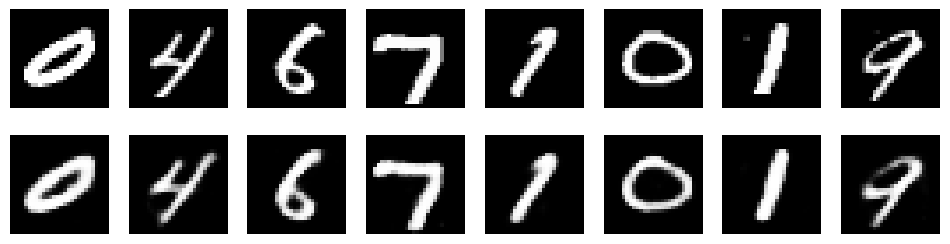

In [32]:
with torch.no_grad():
  x, _ = next(iter(train_loader))
  x = x.view(-1, 784)
  x = x.to(device)

  x_reconstructed = model(x)

  n = 8
  plt.figure(figsize=(12,3))

  for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28,28).cpu().numpy(), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(x_reconstructed[i].view(28,28).cpu().numpy(), cmap='gray')
    plt.axis('off')

plt.show()

# Plotting the latent space and label

In [33]:
model.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

In [34]:
latents = []
labels = []

with torch.no_grad():
  for x, y in train_loader:
    x = x.view(-1, 784)
    x = x.to(device)

    z = model.encoder(x)
    latents.append(z.cpu())
    labels.append(y)

latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)


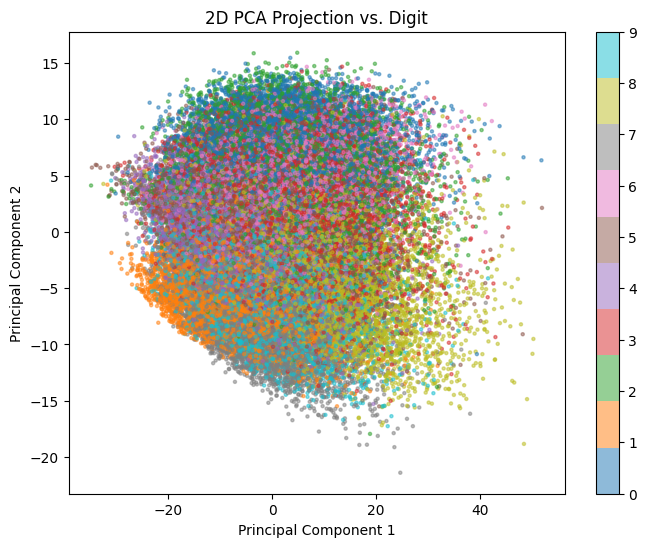

In [35]:
from torch.distributed import scatter
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

latent_dim = latents.shape[1]

# Ensure numpy
Z = latents.detach().cpu().numpy()
y = labels.detach().cpu().numpy()

if latent_dim == 1:
  # -- 1D: Histogram + Strip plot --
  plt.figure(figsize=(8,4))

  for digit in range(10):
    plt.hist(
        Z[y == digit].flatten(),
        bins=20,
        alpha=0.5,
        label=str(digit)
    )

  plt.xlabel('Latent Space')
  plt.ylabel('Frequency')
  plt.title('1D Latent Space Distribution')
  plt.legend()
  plt.show()

  plt.figure(figsize=(8,3))
  plt.scatter(Z.flatten(), y, s=5, alpha=0.5)
  plt.xlabel('Latent Space')
  plt.ylabel('Digit')
  plt.title('1D Latent Space vs. Digit')
  plt.show()


elif latent_dim == 2:
  # -- 2D: Scatter plot --
  plt.figure(figsize=(8,6))
  scatter = plt.scatter(Z[:,0], Z[:,1], c=y, cmap="tab10", s=5, alpha=0.5)
  plt.colorbar(scatter, ticks=range(10))
  plt.xlabel('Latent Space 1')
  plt.ylabel('Latent Space 2')
  plt.title('2D Latent Space vs. Digit')
  plt.show()

else:
  # -- 3D PCA Projection
  pca_dim = 2
  pca = PCA(n_components=pca_dim)
  Z_pca = pca.fit_transform(Z)

  if pca_dim == 2:
    fig = plt.figure(figsize=(8,6))
    scatter = plt.scatter(Z_pca[:,0], Z_pca[:,1], c=y, cmap="tab10", s=5, alpha=0.5)
    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('2D PCA Projection vs. Digit')
    plt.show()
  else:
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(Z_pca[:,0], Z_pca[:,1], Z_pca[:,2], c=y, cmap="tab10", s=5, alpha=0.5)
    plt.colorbar(scatter, ticks=range(10))
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    plt.title('3D PCA Projection vs. Digit')
    plt.show()

# Now play with latent dimension , start with 1,2,3 and so on and see how the above graph groups and changes

# Picking random vector from latent space and passing to decoder to see the reconstruction

In [36]:
model.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

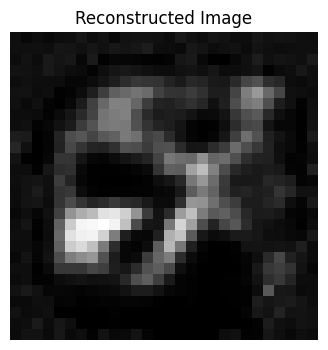

In [37]:
with torch.no_grad():
  latent_dim = model.encoder[-2].out_features # or just use the value you passed
  z.random = torch.randn(1, latent_dim).to(device)
  x_reconstructed = model.decoder(z.random)
  x_reconstructed = x_reconstructed.cpu().view(28,28)

  plt.figure(figsize=(4,4))
  plt.imshow(x_reconstructed, cmap='gray')
  plt.axis('off')
  plt.title('Reconstructed Image')
  plt.show()

In [38]:
# Hence using random value is a waste, to over come this , Variational Auto Encoder came up